# 04 - Repair Backends
Test center-fan and planar triangulation repair on individual samples.

In [1]:
import sys, os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.config import load_config, ensure_dirs
from src.data.dataset_index import DatasetIndex
from src.data.sample_loader import SampleLoader
from src.geometry.boundary import extract_boundary_loops, loop_perimeter
from src.target_selection.selectors import select_target_loops_by_bbox, select_largest_loop
from src.repair.center_fan import center_fan_repair
from src.repair.planar_patch import planar_triangulation_repair
from src.io.mesh_io import save_mesh

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
cfg = load_config(os.path.join(PROJECT_ROOT, 'configs', 'chair_leg.yaml'))
ensure_dirs(cfg)
index = DatasetIndex(cfg['paths']['raw_data_dir'])
loader = SampleLoader(cfg['paths']['raw_data_dir'])
margin = cfg['repair']['margin']
prox_thresh = cfg['repair']['proximity_threshold']

In [3]:
def visualize_repair(damaged_mesh, repaired_mesh, repair_result, title=""):
    """Visualize the repair patch on a mesh."""
    fig = plt.figure(figsize=(12, 5))

    # Plot damaged mesh boundary loops
    ax1 = fig.add_subplot(121, projection='3d')
    loops = extract_boundary_loops(damaged_mesh)
    for loop in loops:
        verts = damaged_mesh.vertices[loop]
        verts_closed = np.vstack([verts, verts[0:1]])
        ax1.plot(verts_closed[:, 0], verts_closed[:, 1], verts_closed[:, 2],
                 linewidth=2)
    ax1.set_title(f'Damaged Mesh ({len(loops)} loops)')
    _set_equal_axes(ax1, damaged_mesh.vertices)

    # Plot repaired mesh with new faces highlighted
    ax2 = fig.add_subplot(122, projection='3d')
    new_faces = repair_result.get('new_faces', np.empty((0,3), dtype=int))
    if len(new_faces) > 0:
        verts = repaired_mesh.vertices
        polys = []
        for face in new_faces:
            tri = verts[face]
            polys.append(tri)
        pc = Poly3DCollection(polys, alpha=0.6, facecolor='orange', edgecolor='black', linewidth=0.5)
        ax2.add_collection3d(pc)
    ax2.set_title(f'Repair Patch ({len(new_faces)} faces)')
    _set_equal_axes(ax2, repaired_mesh.vertices)

    plt.suptitle(title)
    plt.tight_layout()
    return fig

def _set_equal_axes(ax, vertices):
    """Set equal aspect ratio for 3D plot."""
    max_range = (vertices.max(axis=0) - vertices.min(axis=0)).max() / 2
    mid = vertices.mean(axis=0)
    ax.set_xlim(mid[0] - max_range, mid[0] + max_range)
    ax.set_ylim(mid[1] - max_range, mid[1] + max_range)
    ax.set_zlim(mid[2] - max_range, mid[2] + max_range)

In [4]:
# Test on first sample
sid = index.sample_ids[0]
sample = loader.load(sid)
damaged = sample['damaged_mesh']
removed = sample['removed_part_mesh']

loops = extract_boundary_loops(damaged)
print(f"Sample {sid}: {len(loops)} boundary loops")

# Select targets
target_loops = select_target_loops_by_bbox(damaged, loops, removed, margin, prox_thresh)
print(f"RPA selected {len(target_loops)} target loops")

Sample 2882: 128 boundary loops
RPA selected 40 target loops


Center-fan: 40 new verts, 1488 new faces


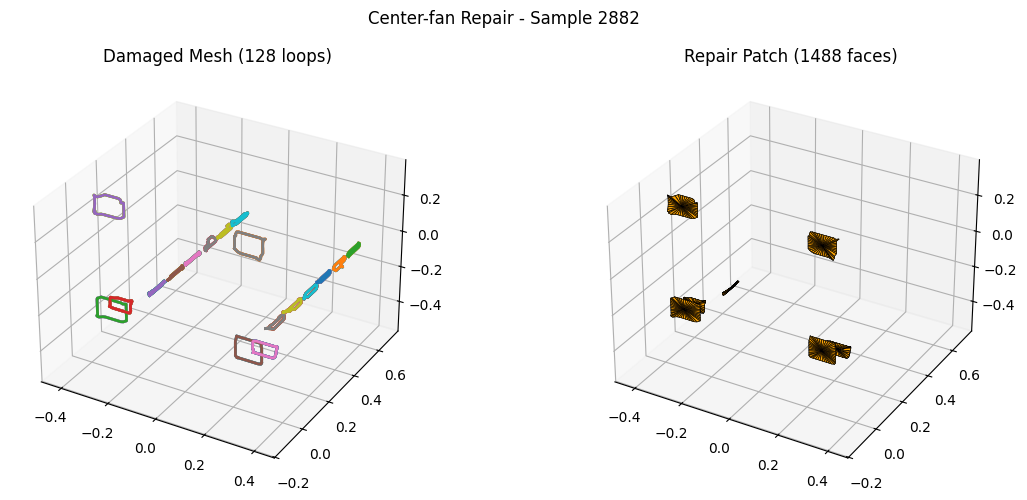

In [5]:
# Center-fan repair
result_cf = center_fan_repair(damaged, target_loops)
print(f"Center-fan: {result_cf['n_new_vertices']} new verts, {result_cf['n_new_faces']} new faces")

fig = visualize_repair(damaged, result_cf['repaired_mesh'], result_cf,
                       f"Center-fan Repair - Sample {sid}")
plt.savefig(os.path.join(cfg['paths']['figures_dir'], f'repair_center_fan_{sid}.pdf'),
            dpi=300, bbox_inches='tight')
plt.show()

Planar: 0 new verts, 1408 new faces


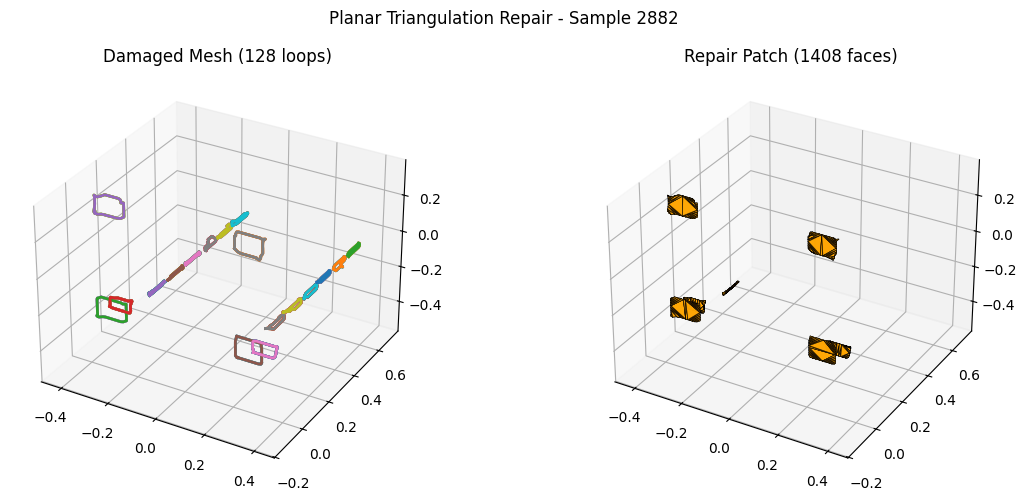

In [6]:
# Planar triangulation repair
result_planar = planar_triangulation_repair(damaged, target_loops)
print(f"Planar: {result_planar['n_new_vertices']} new verts, {result_planar['n_new_faces']} new faces")

fig = visualize_repair(damaged, result_planar['repaired_mesh'], result_planar,
                       f"Planar Triangulation Repair - Sample {sid}")
plt.savefig(os.path.join(cfg['paths']['figures_dir'], f'repair_planar_{sid}.pdf'),
            dpi=300, bbox_inches='tight')
plt.show()

Largest-hole: 0 new verts, 44 new faces


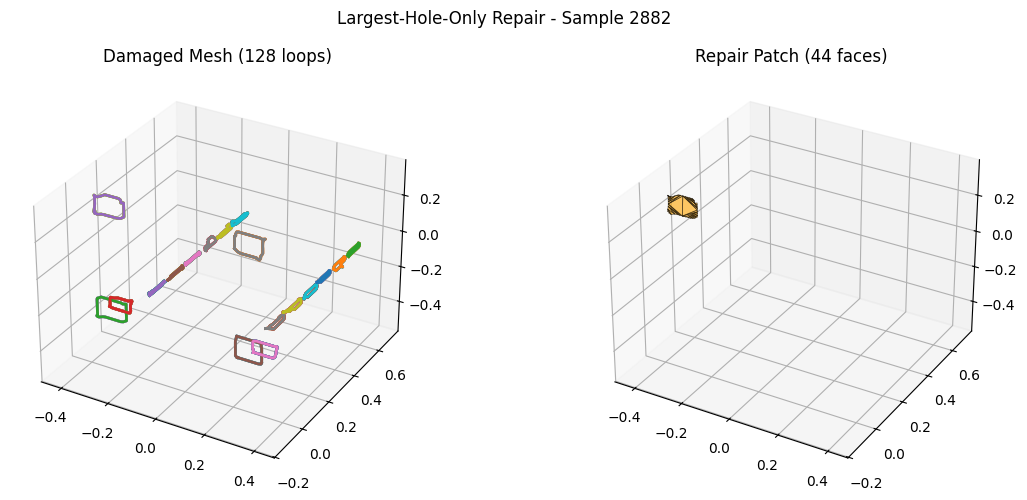

In [7]:
# Largest-hole-only repair
lh_targets = select_largest_loop(damaged, loops)
result_lh = planar_triangulation_repair(damaged, lh_targets)
print(f"Largest-hole: {result_lh['n_new_vertices']} new verts, {result_lh['n_new_faces']} new faces")

fig = visualize_repair(damaged, result_lh['repaired_mesh'], result_lh,
                       f"Largest-Hole-Only Repair - Sample {sid}")
plt.savefig(os.path.join(cfg['paths']['figures_dir'], f'repair_largest_hole_{sid}.pdf'),
            dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# Save repaired meshes
out_dir = os.path.join(cfg['paths']['repaired_meshes_dir'], sid)
os.makedirs(out_dir, exist_ok=True)
save_mesh(result_cf['repaired_mesh'], os.path.join(out_dir, 'repaired_center_fan.obj'))
save_mesh(result_planar['repaired_mesh'], os.path.join(out_dir, 'repaired_planar_rpa.obj'))
save_mesh(result_lh['repaired_mesh'], os.path.join(out_dir, 'repaired_planar_lh.obj'))
print(f"Repaired meshes saved to {out_dir}")

Repaired meshes saved to D:\MyJupyter\Works\3DPART_v2\outputs\repaired_meshes\2882
